# Perturbation Explorer

Visualises how kinematic perturbations shift the focal spot on the receiver target.

**Workflow**
1. **Config cell** — pick a heliostat and set perturbation deltas.
2. **Load scenario** — loads the 63-heliostat HDF5 once (run once, ~30 s on CPU).
3. **Load test data** — reads sun positions for 50 test samples from the PAINT benchmark.
4. **Forward passes** — ray-traces clean and perturbed versions for all 50 sun positions.
5. **Grid display** — 50 side-by-side (clean | perturbed) flux image pairs.
6. **Scatter plot** — centroid shift vs. sun elevation across all 50 samples.

In [15]:
import json, sys, pathlib, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import h5py
warnings.filterwarnings("ignore")

_nb   = pathlib.Path(globals().get("__vsc_ipynb_file__", pathlib.Path().resolve() / "x")).parent  # notebook dir
_src  = _nb.parent                 # .../src
_base = _src.parent                # .../master-thesis
sys.path.insert(0, str(_src))

from artist.raytracing.heliostat_ray_tracer import HeliostatRayTracer
from artist.io.paint_calibration_parser import PaintCalibrationDataParser
from artist.scenario.scenario import Scenario
from artist.util import get_device, set_logger_config
from artist.geometry import bitmap_coordinates_to_target_coordinates
from artist.flux import get_center_of_mass
import paint.util.paint_mappings as paint_mappings

from utils.synth_data import _forward_pass, apply_perturbations, reset_perturbations, _equalize_mapping
from utils.evaluation import build_heliostat_data_mapping

set_logger_config()
import logging; logging.getLogger().setLevel(logging.WARNING)
print("Imports OK")

Imports OK


In [16]:
# ============================================================
#  CONFIG — edit this cell, then re-run all cells below
# ============================================================

# Select one heliostat (ordered by increasing distance from the target)
HELIOSTAT_ID = "AC36"   # options: AC36  AG33  AO34  AW36  BE35

# Kinematic perturbation deltas added to the clean (unperturbed) parameters.
# Set all values to 0.0 for the unperturbed reference.
PERTURBATIONS = {
    # 4 joint-rotation deviations (rad)
    # [0] first_joint_tilt_n  [1] first_joint_tilt_u
    # [2] second_joint_tilt_e [3] second_joint_tilt_n
    "rotation_rad":       [0.05, 0.0, 0.0, 0.0],

    # 2 actuator initial-angle deviations a_i (rad)
    "actuator_angle_rad": [0.0, 0.0],

    # 2 actuator stroke-length deviations b_i (m)
    "actuator_stroke_m":  [0.0, 0.0],

    # 2 actuator offset deviations c_i (m)
    "actuator_offset_m":  [0.0, 0.0],

    # 9 joint + concentrator translation deviations (m)
    # [0-2] first_joint E/N/U  [3-5] second_joint E/N/U  [6-8] concentrator E/N/U
    "translation_m":      [0.0] * 9,

    # 3 heliostat base-position offset in ENU (m)
    "base_position_m":    [0.0, 0.0, 0.0],
}

N_RAYS                 = 100   # rays per light source (higher = cleaner, slower)
SURFACE_POINTS_PER_FACET = 5   # per facet (5×5 = 25 pts); increase for more surface detail

In [17]:
%%time
# ── Load scenario (run once) ──────────────────────────────────────────────

SCENARIO_PATH = _base / "scenarios" / "full_field_200_samples_scenario" / "scenario.h5"

device = get_device()
print(f"Device: {device}")

with h5py.File(SCENARIO_PATH, "r") as f:
    scenario = Scenario.load_scenario_from_hdf5(
        scenario_file=f,
        device=device,
        number_of_surface_points_per_facet=torch.tensor(
            [SURFACE_POINTS_PER_FACET, SURFACE_POINTS_PER_FACET]
        ),
    )

heliostat_group = scenario.heliostat_field.heliostat_groups[0]
heliostat_names = list(heliostat_group.names)
heliostat_idx   = heliostat_names.index(HELIOSTAT_ID)

print(f"Scenario: {len(heliostat_names)} heliostats")
print(f"Selected: {HELIOSTAT_ID}  (index {heliostat_idx})")

[2026-05-25 18:02:46,138][artist.util.env][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-05-25 18:02:46,138][artist.util.env][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-05-25 18:02:46,138][artist.util.env][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-05-25 18:02:46,145][artist.util.env][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
[2026-05-25 18:02:46,145][artist.util.env][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
[2026-05-25 18:02:46,145][artist.util.env][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
Device: cpu
[2026-05-25 18:02:46,147][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2026-05-25 18:02:46,147][artist.scenario.scenario]

In [18]:
%%time
# ── Load 50 test sun positions for the selected heliostat ────────────────

BENCHMARK_NAME = "benchmark_split-balanced_train-100_validation-50_deflectometry"
PAINT_DIR      = _base / "datasets" / "paint"
BENCHMARK_CSV  = PAINT_DIR / "splits" / f"{BENCHMARK_NAME}.csv"
CAL_DIR        = PAINT_DIR / BENCHMARK_NAME / "calibration_properties"
FLUX_DIR       = PAINT_DIR / BENCHMARK_NAME / "flux_image"

full_mapping = build_heliostat_data_mapping(
    benchmark_csv=BENCHMARK_CSV,
    calibration_properties_dir=CAL_DIR,
    flux_image_dir=FLUX_DIR,
    split="test",
)

heli_mapping = [(hid, cal, flux) for hid, cal, flux in full_mapping if hid == HELIOSTAT_ID]
if not heli_mapping:
    raise RuntimeError(f"{HELIOSTAT_ID} not found in test split")

n_samples = len(heli_mapping[0][1])
print(f"Test samples for {HELIOSTAT_ID}: {n_samples}")

equalized = _equalize_mapping(heli_mapping, sample_limit=n_samples)

parser = PaintCalibrationDataParser(
    sample_limit=n_samples,
    centroid_extraction_method=paint_mappings.UTIS_KEY,
)
with torch.no_grad():
    _, _, incident_rays, _, active_mask, target_mask = parser.parse_data_for_reconstruction(
        heliostat_data_mapping=equalized,
        heliostat_group=heliostat_group,
        scenario=scenario,
        device=device,
    )

print(f"Active instances : {int(active_mask.sum())}  ({HELIOSTAT_ID} × {n_samples} samples)")
print(f"incident_rays    : {incident_rays.shape}")

Test samples for AC36: 49
[2026-05-25 18:02:46,567][artist.io.calibration_parser][INFO] - Rank 0: Beginning extraction of flux distributions from .png files.
[2026-05-25 18:02:46,567][artist.io.calibration_parser][INFO] - Rank 0: Beginning extraction of flux distributions from .png files.
[2026-05-25 18:02:46,567][artist.io.calibration_parser][INFO] - Rank 0: Beginning extraction of flux distributions from .png files.
[2026-05-25 18:02:46,586][artist.io.calibration_parser][INFO] - Rank 0: Loading measured flux density distributions complete.
[2026-05-25 18:02:46,586][artist.io.calibration_parser][INFO] - Rank 0: Loading measured flux density distributions complete.
[2026-05-25 18:02:46,586][artist.io.calibration_parser][INFO] - Rank 0: Loading measured flux density distributions complete.
[2026-05-25 18:02:46,586][artist.io.paint_calibration_parser][INFO] - Beginning extraction of calibration properties data from PAINT file.
[2026-05-25 18:02:46,586][artist.io.paint_calibration_parser]

In [19]:
%%time
# ── Run clean + perturbed forward passes ─────────────────────────────────

def _make_pert_tensors(heli_idx: int, config_pert: dict, n_heli: int, device) -> dict:
    """Build [N_heli, ...] perturbation tensors with delta only at heli_idx."""
    p = config_pert
    pert = {
        "rotation":        torch.zeros(n_heli, 4, device=device),
        "actuator_angle":  torch.zeros(n_heli, 2, device=device),
        "actuator_stroke": torch.zeros(n_heli, 2, device=device),
        "actuator_offset": torch.zeros(n_heli, 2, device=device),
        "translation":     torch.zeros(n_heli, 9, device=device),
        "base_position":   torch.zeros(n_heli, 3, device=device),
    }
    pert["rotation"][heli_idx]        = torch.tensor(p["rotation_rad"],       dtype=torch.float32)
    pert["actuator_angle"][heli_idx]  = torch.tensor(p["actuator_angle_rad"], dtype=torch.float32)
    pert["actuator_stroke"][heli_idx] = torch.tensor(p["actuator_stroke_m"],  dtype=torch.float32)
    pert["actuator_offset"][heli_idx] = torch.tensor(p["actuator_offset_m"],  dtype=torch.float32)
    pert["translation"][heli_idx]     = torch.tensor(p["translation_m"],      dtype=torch.float32)
    pert["base_position"][heli_idx]   = torch.tensor(p["base_position_m"],    dtype=torch.float32)
    return pert


scenario.set_number_of_rays(N_RAYS)
n_heli     = len(heliostat_names)
pert_t     = _make_pert_tensors(heliostat_idx, PERTURBATIONS, n_heli, device)
zero_base  = torch.zeros(n_heli, 3, device=device)

print("Running clean forward pass …")
with torch.no_grad():
    clean_centroids, clean_flux = _forward_pass(
        scenario, heliostat_group, incident_rays, active_mask, target_mask,
        zero_base, device,
    )
print(f"  clean flux: {clean_flux.shape}")

print("Applying perturbations and running perturbed forward pass …")
snapshot = apply_perturbations(heliostat_group.kinematics, pert_t, device)
with torch.no_grad():
    pert_centroids, pert_flux = _forward_pass(
        scenario, heliostat_group, incident_rays, active_mask, target_mask,
        pert_t["base_position"], device,
    )
reset_perturbations(heliostat_group.kinematics, snapshot)
print(f"  perturbed flux: {pert_flux.shape}")

# Euclidean centroid shift per sample (ENU, ignoring w)
shifts_m = torch.norm(pert_centroids[:, :3] - clean_centroids[:, :3], dim=1)
print(f"\nCentroid shift — mean: {shifts_m.mean():.3f} m  "
      f"median: {shifts_m.median():.3f} m  "
      f"max: {shifts_m.max():.3f} m")

Running clean forward pass …
  clean flux: torch.Size([49, 256, 256])
Applying perturbations and running perturbed forward pass …
  perturbed flux: torch.Size([49, 256, 256])

Centroid shift — mean: 3.759 m  median: 3.895 m  max: 4.116 m
CPU times: user 263 ms, sys: 78.7 ms, total: 342 ms
Wall time: 87.9 ms


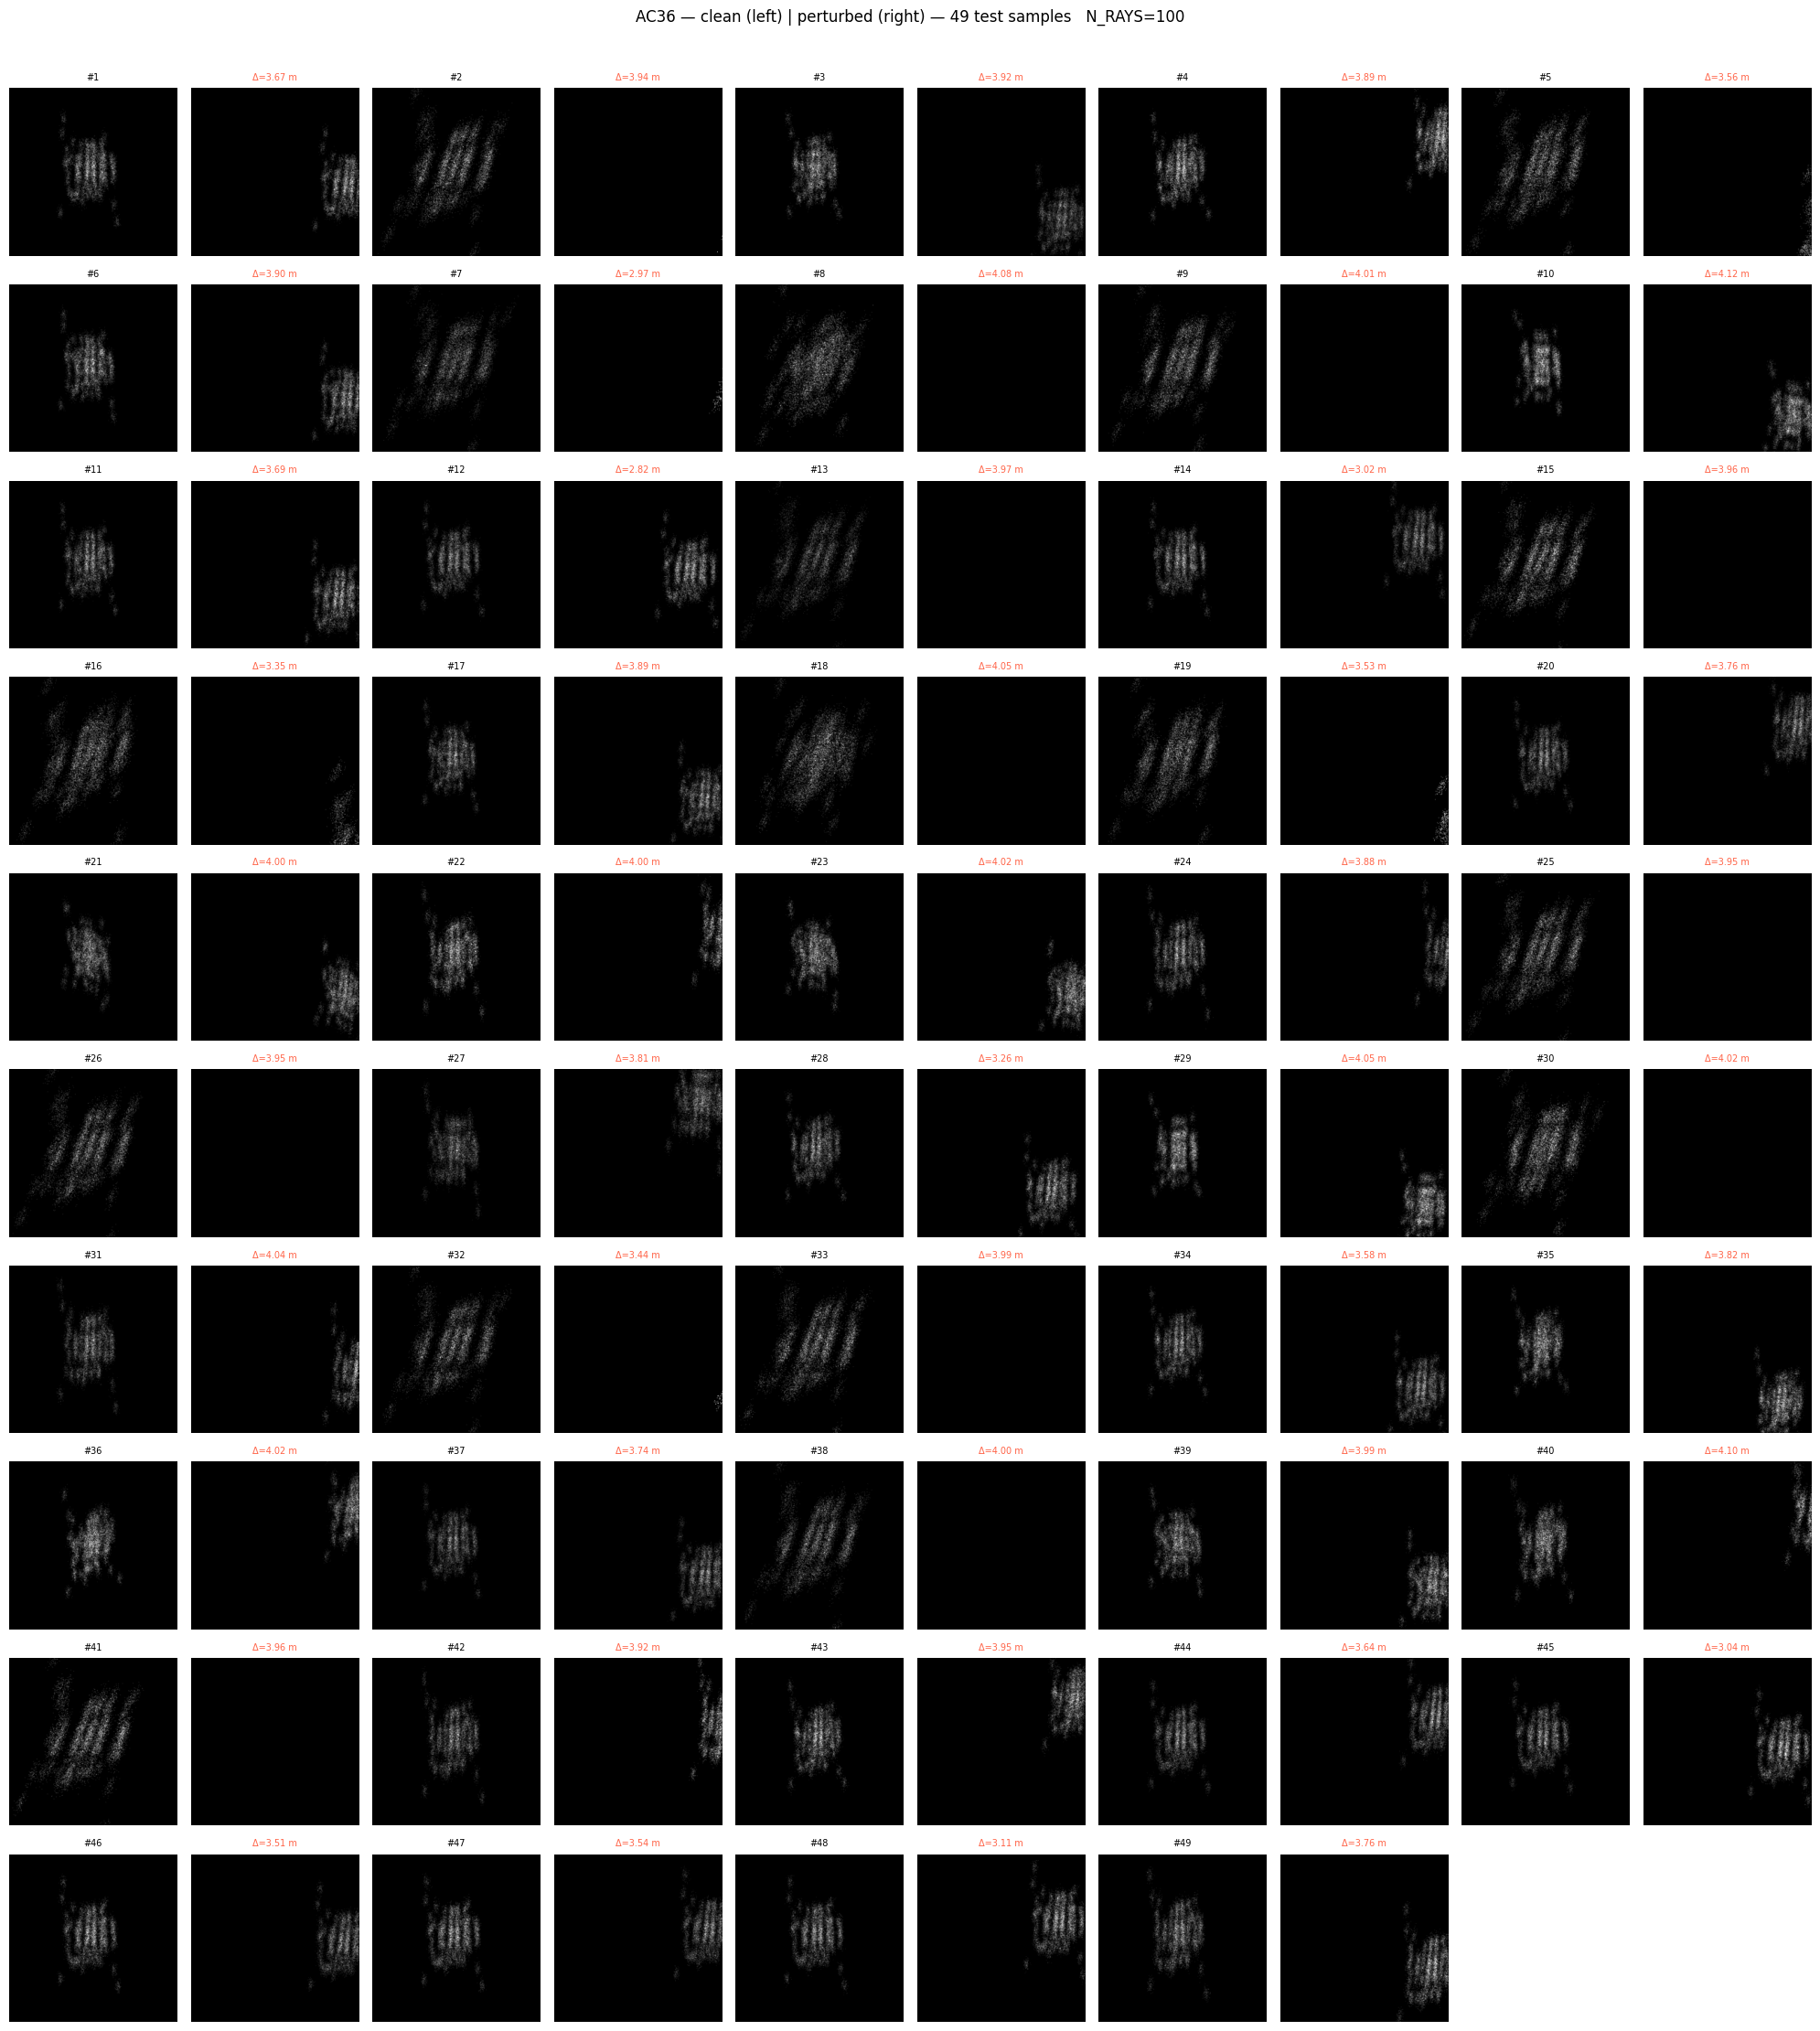

In [20]:
# ── Grid: 50 pairs (clean | perturbed) ───────────────────────────────────

def _to_uint8(flux: torch.Tensor) -> np.ndarray:
    f = flux.cpu().float()
    fmax = f.max()
    if fmax > 1e-12:
        f = f / fmax
    return (f * 255).clamp(0, 255).to(torch.uint8).numpy()


N            = clean_flux.shape[0]   # 50
PAIRS_PER_ROW = 5
ROWS          = (N + PAIRS_PER_ROW - 1) // PAIRS_PER_ROW

fig, axes = plt.subplots(
    ROWS, PAIRS_PER_ROW * 2,
    figsize=(PAIRS_PER_ROW * 4, ROWS * 2.2),
)
fig.suptitle(
    f"{HELIOSTAT_ID} — clean (left) | perturbed (right) — "
    f"{N} test samples   N_RAYS={N_RAYS}",
    fontsize=12, y=1.01,
)

for i in range(N):
    row      = i // PAIRS_PER_ROW
    col_pair = i % PAIRS_PER_ROW
    ax_c = axes[row, col_pair * 2]
    ax_p = axes[row, col_pair * 2 + 1]

    ax_c.imshow(_to_uint8(clean_flux[i]), cmap="gray", vmin=0, vmax=255)
    ax_p.imshow(_to_uint8(pert_flux[i]),  cmap="gray", vmin=0, vmax=255)

    ax_c.set_title(f"#{i+1}", fontsize=7)
    ax_p.set_title(f"\u0394={shifts_m[i]:.2f} m", fontsize=7, color="tomato")
    ax_c.axis("off")
    ax_p.axis("off")

# Hide any unused axes (when N is not a multiple of PAIRS_PER_ROW)
for j in range(N * 2, ROWS * PAIRS_PER_ROW * 2):
    axes.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

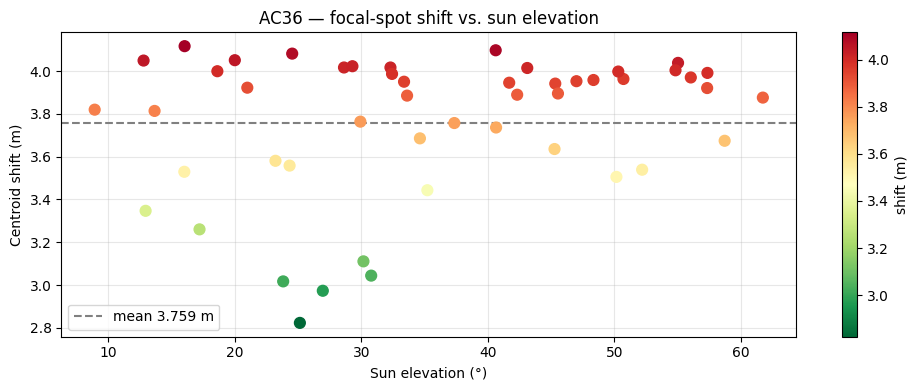

In [21]:
# ── Centroid shift vs. sun elevation ─────────────────────────────────────
# incident ray direction points FROM sun TOWARD scene → elevation = arcsin(-U)

sun_el_deg = torch.asin(-incident_rays[:, 2].clamp(-1, 1)).rad2deg().cpu().numpy()
shifts_np  = shifts_m.cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 4))
sc = ax.scatter(sun_el_deg, shifts_np, c=shifts_np, cmap="RdYlGn_r", s=60, zorder=3)
ax.axhline(shifts_m.mean().item(), ls="--", color="gray",
           label=f"mean {shifts_m.mean():.3f} m")
ax.set_xlabel("Sun elevation (°)")
ax.set_ylabel("Centroid shift (m)")
ax.set_title(f"{HELIOSTAT_ID} — focal-spot shift vs. sun elevation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label="shift (m)")
plt.tight_layout()
plt.show()